In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

# Load dataset:
df_full = pd.read_csv("Final_Master_Dataset.csv")

gdp_df = df_full[[
    "Country",
    "Year",
    "D_Expenditure_GDP",
    "GDP_Growth_Annual",
    "GDP_PerCapita_Growth_Annual",
    "Inflation_Annual",
    "Unemployment_Total_of_TLF",
    "Population"
]].copy()

gdp_df.columns = [
    "Country",
    "Year",
    "Defense_GDP",
    "GDP_Growth",
    "GDP_PC_Growth",
    "Inflation",
    "Unemployment",
    "Population"
]

gdp_df = gdp_df.sort_values(["Country", "Year"]).reset_index(drop=True)

# Basic data:
gdp_df.info()
gdp_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        155 non-null    object 
 1   Year           155 non-null    int64  
 2   Defense_GDP    155 non-null    float64
 3   GDP_Growth     155 non-null    float64
 4   GDP_PC_Growth  155 non-null    float64
 5   Inflation      155 non-null    float64
 6   Unemployment   155 non-null    float64
 7   Population     155 non-null    int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 9.8+ KB


,Year,Defense_GDP,GDP_Growth,GDP_PC_Growth,Inflation,Unemployment,Population
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,1.550000e+02
mean,2009.000000,2.778980,3.366688,2.860431,7.941282,6.446910,3.806592e+08
std,8.973265,1.026659,4.090402,4.066489,30.073988,2.494112,4.838115e+08
min,1994.000000,1.605260,-12.569800,-12.539800,-1.401470,2.527000,5.786574e+07
25%,2001.000000,1.924853,1.673178,1.070603,1.569155,4.560000,6.521442e+07
50%,2009.000000,2.422716,2.714064,2.117365,2.292840,5.558000,1.446486e+08
75%,2017.000000,3.505406,5.307406,5.535516,4.584113,8.199500,3.254810e+08
max,2024.000000,7.052339,14.149990,13.555370,307.722600,13.261000,1.412360e+09


In [2]:
# Handle missing-values:
gdp_df = gdp_df.groupby("Country").apply(
    lambda x: x.interpolate(method="linear")
).reset_index(drop=True)

gdp_df = gdp_df.dropna().reset_index(drop=True)

/tmp/ipython-input-823/3701419255.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipython-input-823/3701419255.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipython-input-823/3701419255.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipython-input-823/3701419255.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(metho

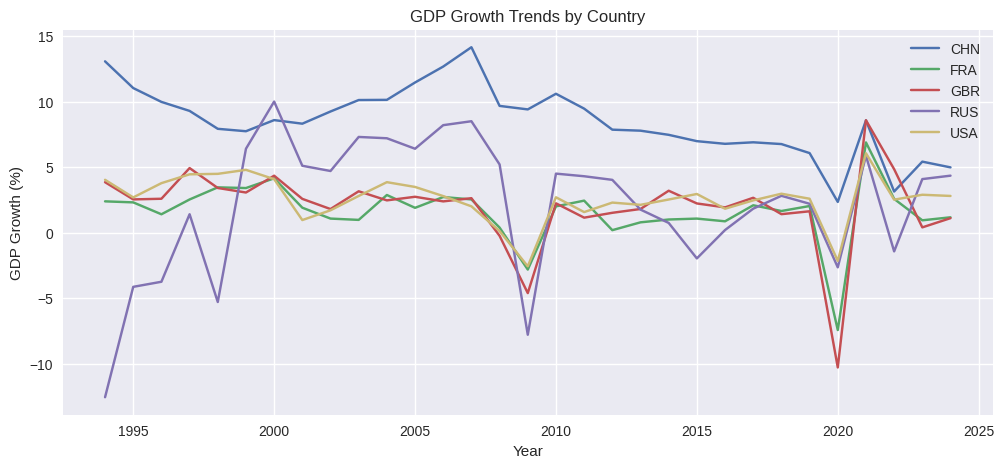

In [3]:
# Explorotary Data Analysis (EDA):
# GDP-Growth Trend per country:

plt.figure(figsize=(12,5))

for country in gdp_df["Country"].unique():
    cdf = gdp_df[gdp_df["Country"] == country]
    plt.plot(cdf["Year"], cdf["GDP_Growth"], label=country)

plt.title("GDP Growth Trends by Country")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.show()

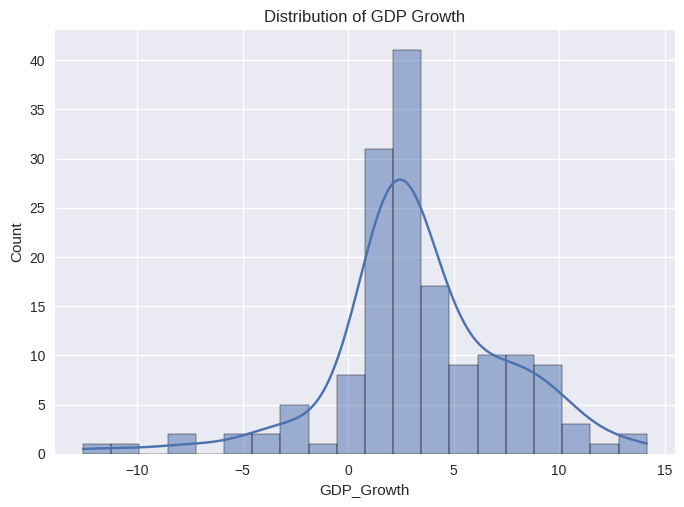

In [4]:
# Distribution of GDP-Growth:
sns.histplot(gdp_df["GDP_Growth"], kde=True)
plt.title("Distribution of GDP Growth")
plt.show()

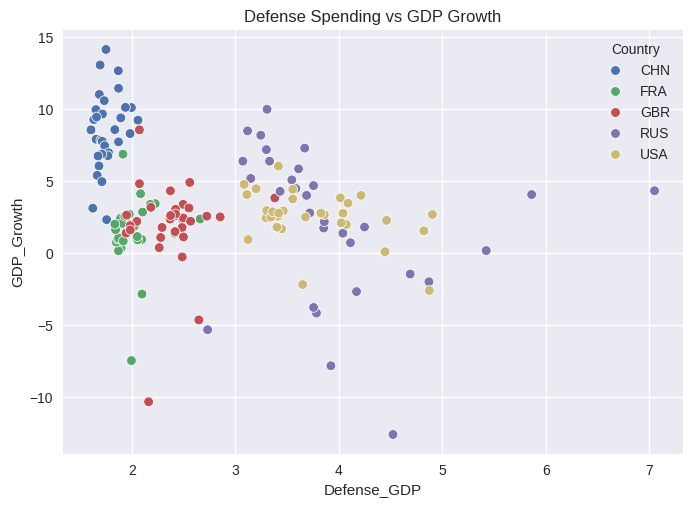

In [5]:
# Defence Expenditure vs GDP-Growth:
sns.scatterplot(
    data=gdp_df,
    x="Defense_GDP",
    y="GDP_Growth",
    hue="Country"
)
plt.title("Defense Spending vs GDP Growth")
plt.show()

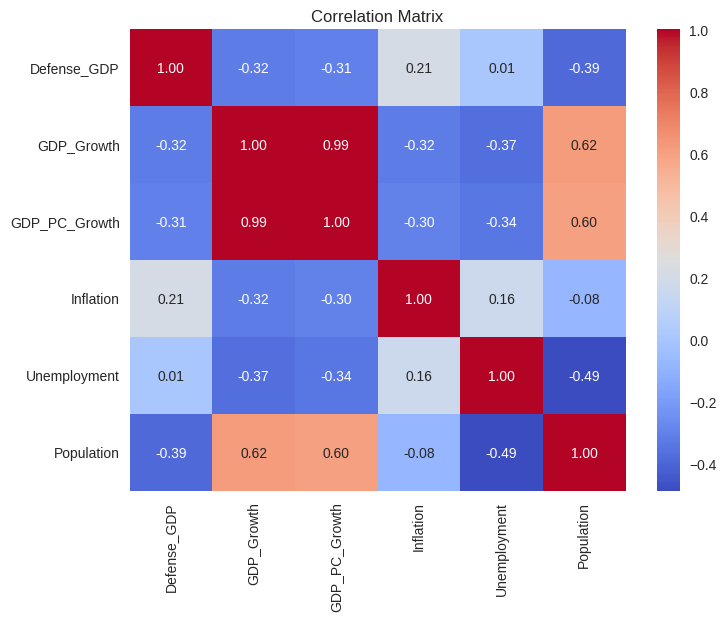

In [6]:
# Correlation-Matrix:
plt.figure(figsize=(8,6))
sns.heatmap(
    gdp_df.drop(columns=["Country","Year"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

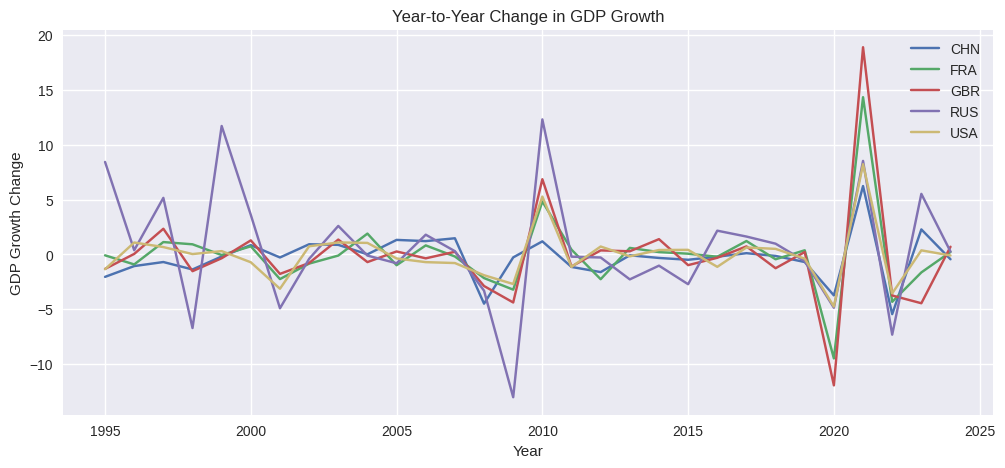

In [7]:
# Stationarity-check:
gdp_df["GDP_Delta"] = gdp_df.groupby("Country")["GDP_Growth"].diff()

plt.figure(figsize=(12,5))

for country in gdp_df["Country"].unique():
    cdf = gdp_df[gdp_df["Country"] == country]
    plt.plot(cdf["Year"], cdf["GDP_Delta"], label=country)

plt.title("Year-to-Year Change in GDP Growth")
plt.xlabel("Year")
plt.ylabel("GDP Growth Change")
plt.legend()
plt.show()